# NYC taxi fare analytics

Can we estimate a taxi fare before travel, and how does that compare with reconstructing a completed trip? Yellow is the main fleet; green is a shorter companion comparison. This walkthrough shows the implementation and reads results from the actual full run. See [methodology](../docs/methodology.md) for assumptions.

In [1]:
from pathlib import Path
import json, math, subprocess, sys
from IPython.display import display, Markdown, Image
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from nyc_taxi.config import RULES, FARE_CHANGE_DATE, SEED
from nyc_taxi.pipeline import CATEGORICAL, FEATURE_SETS, EDA_QUERIES
from nyc_taxi.reporting import model_table
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists(): ROOT = ROOT.parent
RECOMPUTE = False
if RECOMPUTE:
    subprocess.run([sys.executable, '-m', 'nyc_taxi.cli', 'run'], cwd=ROOT, check=True)
RESULTS = ROOT / 'docs/results'
def read(path): return json.loads((RESULTS / path).read_text())
def table(rows):
    if not rows: return
    keys = list(rows[0])
    display(Markdown('| ' + ' | '.join(keys) + ' |\n| ' + ' | '.join(['---']*len(keys)) + ' |\n' +
                     '\n'.join('| ' + ' | '.join(str(r.get(k,'')) for k in keys) + ' |' for r in rows)))
experiment = read('experiment.json')


## 1. Source files

Every monthly yellow and green TLC Parquet file in the study period is required. Each file is projected and cast separately before union, allowing monthly numeric type differences without guessing a combined schema.

In [2]:
def normalize(df, fleet):
    prefix = 'tpep' if fleet == 'yellow' else 'lpep'
    types = {'pickup_datetime': 'timestamp', 'dropoff_datetime': 'timestamp',
             'trip_distance': 'double', 'fare_amount': 'double',
             'PULocationID': 'int', 'DOLocationID': 'int'}
    actual = {c.lower(): c for c in df.columns}
    columns = []
    for name, dtype in types.items():
        source = f'{prefix}_{name}' if name.endswith('datetime') else name
        if source.lower() not in actual:
            raise ValueError(f'{fleet}: missing required column {source}')
        columns.append(F.col(actual[source.lower()]).cast(dtype).alias(name))
    return df.select(*columns)


In [3]:
table([{'fleet': f, 'source_files': len(r['source_files']), 'source_rows': r['quality']['source_rows']} for f,r in experiment['fleets'].items()])

| fleet | source_files | source_rows |
| --- | --- | --- |
| yellow | 60 | 174689444 |
| green | 60 | 5090611 |

The source totals describe loaded records, before any population restrictions. Full-data analysis and sampled modelling therefore have different row counts.

## 2. Cleaning and data quality

The following is the actual first-failure filter used by the run. Thresholds are defined once in the configuration file; they define ordinary plausible NYC taxi journeys.

In [4]:
def cleaning_reason(df):
    """First failing rule wins; order is also the rejection report order."""
    distance, fare = F.col('trip_distance'), F.col('fare_amount')
    duration = F.col('duration_minutes')
    return (F.when(F.col('pickup_datetime').isNull() | F.col('dropoff_datetime').isNull(), 'missing_timestamp')
            .when(~F.year('pickup_datetime').between(RULES.first_year, RULES.last_year), 'outside_period')
            .when(distance.isNull() | F.isnan(distance) | (distance <= 0), 'distance_missing_or_nonpositive')
            .when(distance > RULES.max_distance_miles, 'distance_over_limit')
            .when(duration < RULES.min_duration_minutes, 'duration_too_short')
            .when(duration > RULES.max_duration_minutes, 'duration_too_long')
            .when(distance * 60 / duration > RULES.max_average_speed_mph, 'speed_over_limit')
            .when(fare.isNull() | F.isnan(fare) | (fare <= 0), 'fare_missing_or_nonpositive')
            .when(fare > RULES.max_fare_dollars, 'fare_over_limit')
            .otherwise('accepted'))


In [5]:
def clean(df):
    tagged = df.withColumn('duration_minutes',
        (F.col('dropoff_datetime').cast('long') - F.col('pickup_datetime').cast('long')) / 60)
    tagged = tagged.withColumn('quality_reason', cleaning_reason(tagged))
    counts = {r.quality_reason: r['count'] for r in tagged.groupBy('quality_reason').count().collect()}
    accepted = tagged.filter(F.col('quality_reason') == 'accepted').drop('quality_reason')
    return accepted, counts, tagged


In [6]:
from dataclasses import asdict
table([asdict(RULES)])
for fleet, r in experiment['fleets'].items():
    display(Markdown('### '+fleet.title()))
    q=r['quality']
    table([{'reason': k, 'rows': v} for k,v in q['first_failure_counts'].items()])
    assert sum(q['first_failure_counts'].values()) == q['source_rows']
    table(q['examples'])

| first_year | last_year | max_distance_miles | min_duration_minutes | max_duration_minutes | max_average_speed_mph | max_fare_dollars |
| --- | --- | --- | --- | --- | --- | --- |
| 2020 | 2024 | 100.0 | 1.0 | 360.0 | 80.0 | 500.0 |

### Yellow

| reason | rows |
| --- | --- |
| duration_too_short | 815778 |
| accepted | 169430105 |
| outside_period | 1204 |
| fare_missing_or_nonpositive | 1353693 |
| fare_over_limit | 497 |
| duration_too_long | 202685 |
| speed_over_limit | 13969 |
| distance_missing_or_nonpositive | 2863932 |
| distance_over_limit | 7581 |

| pickup_datetime | trip_distance | duration_minutes | fare_amount | quality_reason |
| --- | --- | --- | --- | --- |
| 2024-02-29 13:17:33 | 6860.8 | 38.61666666666667 | 32.5 | distance_over_limit |

### Green

| reason | rows |
| --- | --- |
| duration_too_short | 46878 |
| accepted | 4780936 |
| outside_period | 111 |
| fare_missing_or_nonpositive | 11079 |
| fare_over_limit | 11 |
| duration_too_long | 17252 |
| speed_over_limit | 957 |
| distance_missing_or_nonpositive | 229226 |
| distance_over_limit | 4161 |

### Data quality findings

The source example above is rejected by the distance limit before modelling. Rejection counts are mutually exclusive: a row failing several rules contributes only to its first failure. These assumptions can exclude legitimate unusual journeys; accepted records are positive-recorded-fare trips, not proof of payment.

## 3. Parquet storage and Spark SQL

The full run writes accepted records to Parquet, then reads them back. This breaks the long monthly input plan and provides a reusable cleaned layer.

```python
accepted.write.mode("overwrite").parquet(str(cleaned_path))
accepted = spark.read.parquet(str(cleaned_path))
enriched = features(accepted)
enriched.createOrReplaceTempView("trips")
```

In [7]:
table([{'fleet': f, 'accepted_rows': r['quality']['accepted_rows'], 'cleaning_seconds': round(r['stage_seconds']['cleaning'],2)} for f,r in experiment['fleets'].items()])

| fleet | accepted_rows | cleaning_seconds |
| --- | --- | --- |
| yellow | 169430105 | 518.45 |
| green | 4780936 | 32.24 |

Spark SQL operates on every accepted trip for the following descriptive analysis. Only the smaller modelling sample is cached in memory.

## 4. Exploratory analysis

These are three of the SQL queries executed on the cleaned trips. The distance-band column is derived only for analysis; it is not an extra model input.

```sql
SELECT date_format(pickup_datetime, 'yyyy-MM') month, COUNT(*) trip_count FROM trips GROUP BY 1 ORDER BY 1
```

```sql
SELECT distance_band, COUNT(*) trip_count, AVG(fare_amount) mean_fare FROM trips GROUP BY distance_band ORDER BY MIN(trip_distance)
```

```sql
SELECT DOLocationID, COUNT(*) trip_count, AVG(fare_amount) mean_fare FROM trips WHERE DOLocationID BETWEEN 1 AND 263 GROUP BY DOLocationID HAVING COUNT(*) >= 500 ORDER BY mean_fare DESC, DOLocationID LIMIT 5
```

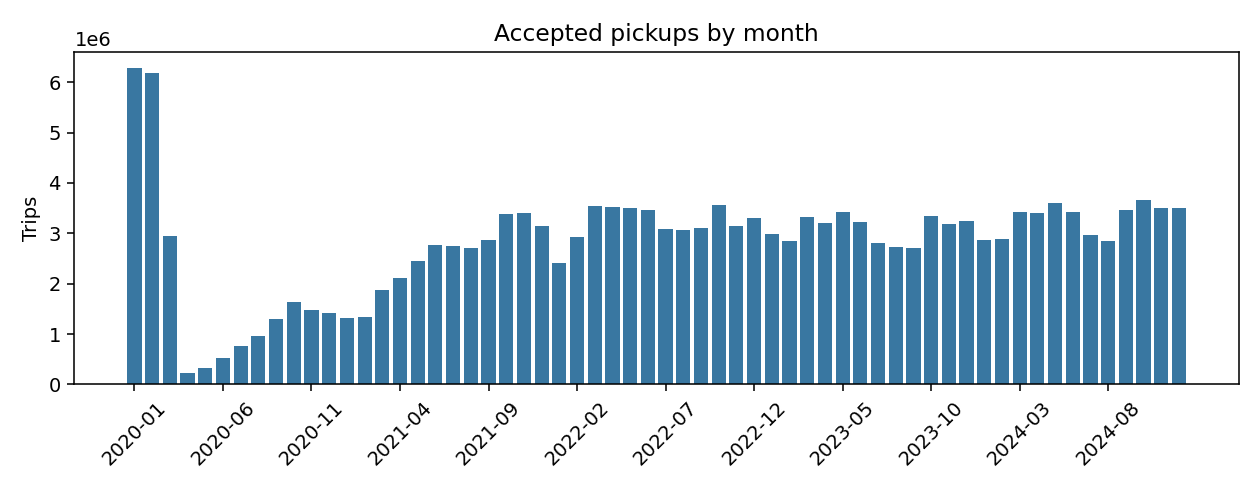

Accepted yellow pickups: 24,061,728 in 2020 and 39,556,497 in 2024. Lowest observed month: 2020-04 (228,428). No pre-pandemic year is available.

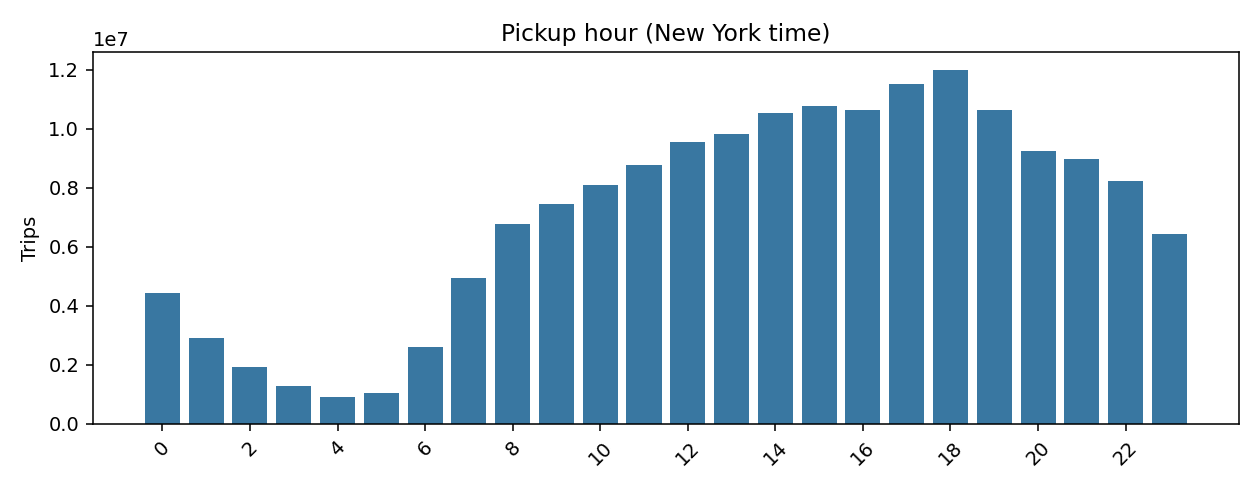

Busiest yellow pickup hour: 18:00, with 11,988,732 trips over the study.

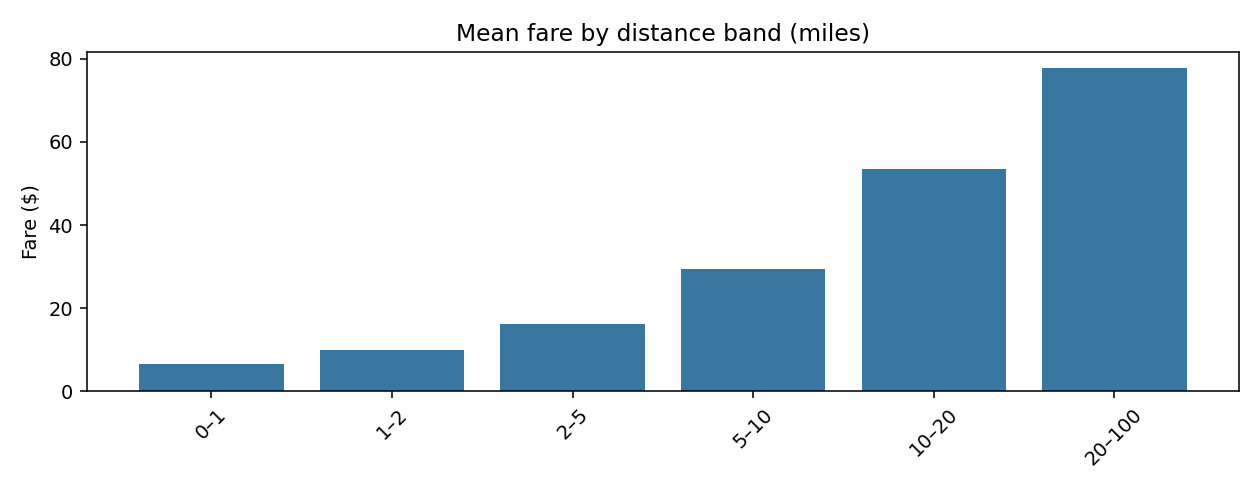

Mean recorded fare rises from USD 6.63 in the 0–1-mile band to USD 77.70 in the 20–100-mile band. This mixes routes and pricing periods.

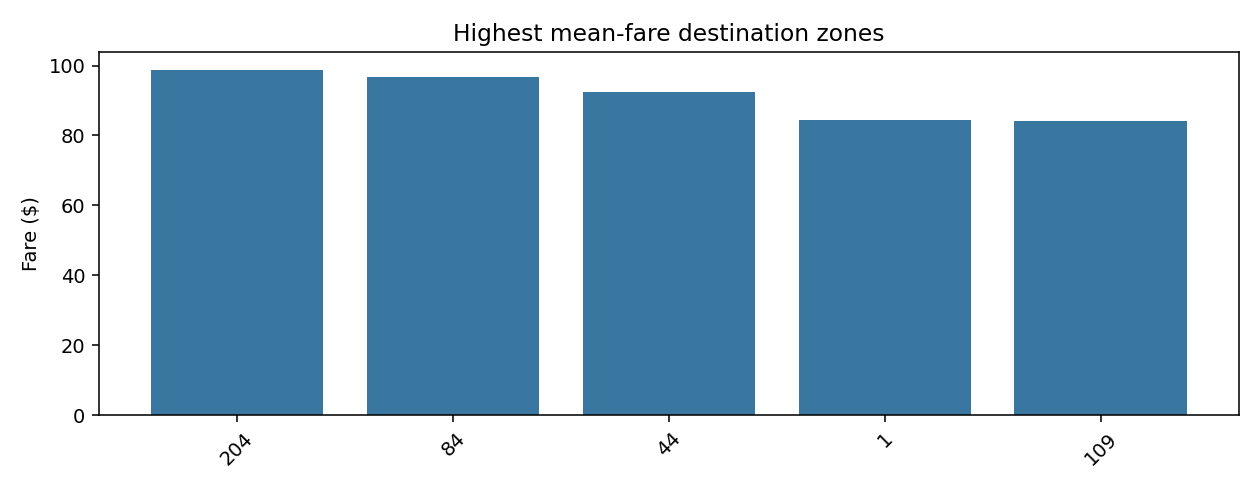

Zone 204 leads mean fare at USD 98.85 over 804 trips. The ranking does not control for distance.

### Green companion

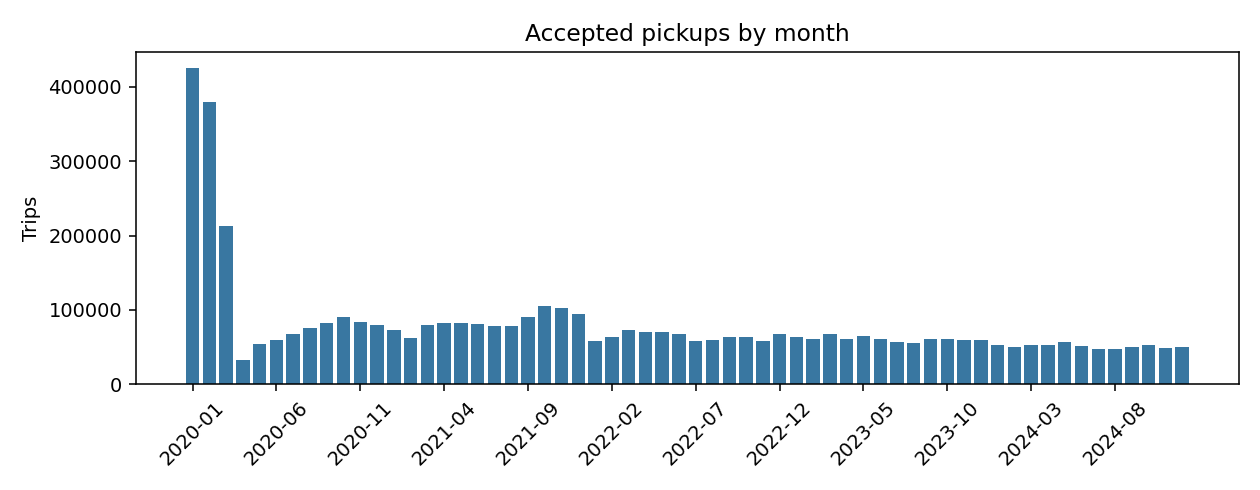

In [8]:
monthly=read('yellow/monthly_trips.json')
years={}
for r in monthly: years[r['month'][:4]]=years.get(r['month'][:4],0)+r['trip_count']
low=min(monthly,key=lambda r:r['trip_count'])
hour=max(read('yellow/hourly_trips.json'),key=lambda r:r['trip_count'])
bands=read('yellow/fare_by_distance.json')
zone=read('yellow/highest_fare_dropoffs.json')[0]
interpretations=[
    f"Accepted yellow pickups: {years['2020']:,} in 2020 and {years['2024']:,} in 2024. Lowest observed month: {low['month']} ({low['trip_count']:,}). No pre-pandemic year is available.",
    f"Busiest yellow pickup hour: {hour['pickup_hour']}:00, with {hour['trip_count']:,} trips over the study.",
    f"Mean recorded fare rises from USD {bands[0]['mean_fare']:.2f} in the {bands[0]['distance_band']}-mile band to USD {bands[-1]['mean_fare']:.2f} in the {bands[-1]['distance_band']}-mile band. This mixes routes and pricing periods.",
    f"Zone {zone['DOLocationID']} leads mean fare at USD {zone['mean_fare']:.2f} over {zone['trip_count']:,} trips. The ranking does not control for distance."
]
for name, text in zip(EDA_QUERIES,interpretations):
    display(Image(filename=str(RESULTS/'yellow'/f'{name}.png')))
    display(Markdown(text))
display(Markdown('### Green companion'))
display(Image(filename=str(RESULTS/'green/monthly_trips.png')))


The charts describe the filtered source population. Demand begins in the first year of the pandemic, and route length can explain much of the destination-fare ranking; these are descriptive findings.

## 5. Features and temporal split

Training uses the earlier period, validation chooses a model, and the final year is held out. Both settings know the destination. Route summaries and category vocabularies learn from the training sample only; unseen pairs fall back to overall training medians. Pre-trip features exclude that trip’s realized distance and duration.

In [9]:
def features(df):
    return (df.withColumn('pickup_hour', F.hour('pickup_datetime'))
            .withColumn('pickup_weekday', F.dayofweek('pickup_datetime'))
            .withColumn('pickup_month', F.month('pickup_datetime'))
            .withColumn('new_fare_regime', (F.col('pickup_datetime') >= F.lit(FARE_CHANGE_DATE).cast('timestamp')).cast('double'))
            .withColumn('distance_band', F.when(F.col('trip_distance') < 1, '0–1')
                        .when(F.col('trip_distance') < 2, '1–2').when(F.col('trip_distance') < 5, '2–5')
                        .when(F.col('trip_distance') < 10, '5–10').when(F.col('trip_distance') < 20, '10–20')
                        .otherwise('20–100')))


In [10]:
def fit_history(training):
    """Route summaries and fallback come exclusively from the training sample."""
    medians = training.groupBy(*CATEGORICAL).agg(
        F.percentile_approx('trip_distance', 0.5, 10000).alias('historical_distance'),
        F.percentile_approx('duration_minutes', 0.5, 10000).alias('historical_duration'))
    fallback = training.agg(F.percentile_approx('trip_distance', 0.5, 10000),
                            F.percentile_approx('duration_minutes', 0.5, 10000)).first()
    return medians, {'historical_distance': fallback[0], 'historical_duration': fallback[1]}


In [11]:
def add_history(df, medians, fallback):
    result = df.join(F.broadcast(medians), CATEGORICAL, 'left')
    return (result.withColumn('unseen_pair', F.col('historical_distance').isNull())
            .fillna(fallback))


In [12]:
def fit_preprocessing(training, feature_set):
    indexers = [StringIndexer(inputCol=c, outputCol=c+'_index', handleInvalid='keep') for c in CATEGORICAL]
    encoder = OneHotEncoder(inputCols=[c+'_index' for c in CATEGORICAL],
                            outputCols=[c+'_ohe' for c in CATEGORICAL], handleInvalid='keep')
    assembler = VectorAssembler(inputCols=FEATURE_SETS[feature_set] + [c+'_ohe' for c in CATEGORICAL], outputCol='features')
    return Pipeline(stages=indexers + [encoder, assembler]).fit(training)


In [13]:
for fleet,r in experiment['fleets'].items():
    m=r['modeling']
    table([{'fleet':fleet,'fraction':m['sample_fraction'],**m['split_counts'],'train_before':m['train_before'],'test_from':m['test_from'],'test_unseen_pairs':m['test_unseen_pair_rows']}])
    table(m['training_pricing_regimes'])
    table([m['fallback']])
table([{'setting': k, 'numeric_features': ', '.join(v)} for k,v in FEATURE_SETS.items()])

| fleet | fraction | train | validation | test | train_before | test_from | test_unseen_pairs |
| --- | --- | --- | --- | --- | --- | --- | --- |
| yellow | 0.002 | 185235 | 73987 | 79550 | 2023-01-01 | 2024-01-01 | 1882 |

| new_fare_regime | count |
| --- | --- |
| 0.0 | 183044 |
| 1.0 | 2191 |

| historical_distance | historical_duration |
| --- | --- |
| 1.83 | 11.4 |

| fleet | fraction | train | validation | test | train_before | test_from | test_unseen_pairs |
| --- | --- | --- | --- | --- | --- | --- | --- |
| green | 0.05 | 171320 | 36513 | 30691 | 2023-01-01 | 2024-01-01 | 533 |

| new_fare_regime | count |
| --- | --- |
| 0.0 | 169872 |
| 1.0 | 1448 |

| historical_distance | historical_duration |
| --- | --- |
| 2.42 | 13.283333333333333 |

| setting | numeric_features |
| --- | --- |
| pre_trip | pickup_hour, pickup_weekday, pickup_month, new_fare_regime, historical_distance, historical_duration |
| post_trip | pickup_hour, pickup_weekday, pickup_month, new_fare_regime, historical_distance, historical_duration, trip_distance, duration_minutes |

The external fare-change flag becomes true on December 19, 2022. It supplies known pricing information but only a short new-regime window is present in training. This run does not isolate the flag’s accuracy contribution. Post-trip results use additional information unavailable before travel.

## 6. Model comparison and final evaluation

The following excerpt is the actual candidate selection loop. Each feature setting compares linear regression, random forest and GBT by validation RMSE. The training-mean baseline and the two winners are evaluated on the same test rows.

```python
estimators = [LinearRegression(labelCol='fare_amount', regParam=0.1),
              RandomForestRegressor(labelCol='fare_amount', numTrees=20, maxDepth=5, seed=SEED),
              GBTRegressor(labelCol='fare_amount', maxIter=20, maxDepth=4, seed=SEED)]
results, models = [], []
for estimator in estimators:
    model = estimator.fit(train_vec)
    score = regression_metrics(model.transform(valid_vec))
    results.append({'model': type(estimator).__name__, **score}); models.append(model)
    print(f'{setting}: {type(estimator).__name__} validation RMSE {score["rmse"]:.3f}', flush=True)
winner = min(range(len(results)), key=lambda i: results[i]['rmse'])
predictions = models[winner].transform(preprocessing.transform(history[2])).cache()
score = regression_metrics(predictions)
```

In [14]:
def regression_metrics(predictions):
    # One aggregation avoids repeatedly scanning predictions for each metric.
    row = predictions.agg(F.count('*').alias('n'), F.avg('fare_amount').alias('mean'),
        F.var_pop('fare_amount').alias('variance'),
        F.avg(F.abs(F.col('prediction')-F.col('fare_amount'))).alias('mae'),
        F.avg((F.col('prediction')-F.col('fare_amount'))**2).alias('mse'),
        (100*F.avg((F.abs(F.col('prediction')-F.col('fare_amount'))<=2).cast('double'))).alias('within_2_pct'),
        (100*F.avg((F.abs(F.col('prediction')-F.col('fare_amount'))<=5).cast('double'))).alias('within_5_pct')).first()
    return {'mae': row.mae, 'rmse': math.sqrt(row.mse),
            'r2': 1-row.mse/row.variance if row.variance else None,
            'within_2_pct': row.within_2_pct, 'within_5_pct': row.within_5_pct}


In [15]:
for fleet,r in experiment['fleets'].items():
    display(Markdown('### '+fleet.title()))
    table([{'setting':s,**v} for s,m in r['modeling']['feature_sets'].items() for v in m['validation']])
display(Markdown(model_table(experiment)))
for fleet in experiment['fleets']:
    for setting in FEATURE_SETS:
        display(Markdown(f'### {fleet.title()}: {setting} errors by fare band'))
        table(read(f'{fleet}/{setting}_error_by_fare.json'))
        if fleet=='yellow':
            display(Markdown('Largest absolute test residuals after filtering'))
            table(read(f'{fleet}/{setting}_worst_errors.json'))
display(Markdown(f"Full run: {experiment['elapsed_seconds']/60:.2f} minutes. Environment: Spark {experiment['environment']['spark']}, {experiment['environment']['master']}, {experiment['environment']['driver_memory']} driver."))

### Yellow

| setting | model | mae | rmse | r2 | within_2_pct | within_5_pct |
| --- | --- | --- | --- | --- | --- | --- |
| pre_trip | LinearRegression | 4.8785244669221335 | 8.393592244499176 | 0.7681781913133372 | 28.103585765066835 | 69.80820955032641 |
| pre_trip | RandomForestRegressor | 5.580402552549132 | 9.831649356217238 | 0.6819383431895608 | 35.01831402814008 | 63.817968021409165 |
| pre_trip | GBTRegressor | 3.8886640258410954 | 7.979629502681728 | 0.790480712111151 | 44.68893183937719 | 80.65470961114791 |
| post_trip | LinearRegression | 3.5341778597521016 | 5.844377574007572 | 0.8876080811652365 | 35.783313284766244 | 86.33138254017597 |
| post_trip | RandomForestRegressor | 4.597984179869909 | 7.867563742343451 | 0.7963243574579177 | 37.08083852568694 | 71.27468339032534 |
| post_trip | GBTRegressor | 1.9408359649165534 | 4.728670727943573 | 0.9264239104232994 | 74.87396434508766 | 93.10960033519402 |

### Green

| setting | model | mae | rmse | r2 | within_2_pct | within_5_pct |
| --- | --- | --- | --- | --- | --- | --- |
| pre_trip | LinearRegression | 4.560608513760795 | 10.28142092118873 | 0.5157139017517062 | 41.20450250595678 | 77.03009886889602 |
| pre_trip | RandomForestRegressor | 5.05296943179213 | 11.207857296690431 | 0.4245058559123981 | 38.55613069317777 | 73.67786815654699 |
| pre_trip | GBTRegressor | 4.661970492392714 | 10.81122136173896 | 0.46451754862595807 | 42.625914058006735 | 76.97806260783831 |
| post_trip | LinearRegression | 3.1332831557255285 | 7.212973500326724 | 0.7616449285670019 | 54.692849122230434 | 85.65442445156519 |
| post_trip | RandomForestRegressor | 3.8207616547215335 | 8.715642314810896 | 0.6519877583384 | 46.977788732780105 | 81.10809848547092 |
| post_trip | GBTRegressor | 2.983923945542088 | 7.411026913491676 | 0.7483757436801486 | 58.55996494399255 | 86.59929340234986 |

| Fleet / setting | Selected model | MAE ($) | RMSE ($) | R² | Within $2 | Within $5 |
|---|---|---:|---:|---:|---:|---:|
| Yellow / Mean baseline | Training mean | 10.42 | 18.57 | -0.120 | 19.3% | 44.9% |
| Yellow / pre-trip | GBT | 4.29 | 8.63 | 0.758 | 42.4% | 77.7% |
| Yellow / post-trip | GBT | 2.26 | 5.42 | 0.905 | 71.9% | 90.7% |
| Green / Mean baseline | Training mean | 8.93 | 15.26 | -0.001 | 15.6% | 36.6% |
| Green / pre-trip | LinearRegression | 4.79 | 11.00 | 0.479 | 41.0% | 76.2% |
| Green / post-trip | LinearRegression | 3.36 | 8.23 | 0.709 | 55.7% | 84.9% |

...

### Green: pre_trip errors by fare band

| fare_band | rows | mae | rmse |
| --- | --- | --- | --- |
| 20_to_50 | 6820 | 7.317300877508577 | 9.2398610820192 |
| 50_plus | 1089 | 38.132800013329394 | 51.415067096531125 |
| under_20 | 22782 | 2.439595046960045 | 3.3491577703053035 |

### Green: post_trip errors by fare band

| fare_band | rows | mae | rmse |
| --- | --- | --- | --- |
| 20_to_50 | 6820 | 5.307005006006923 | 6.475186847910726 |
| 50_plus | 1089 | 27.143239484049012 | 39.03704999201094 |
| under_20 | 22782 | 1.6354773007933534 | 2.408202774120828 |

Full run: 16.36 minutes. Environment: Spark 3.5.3, local[2], 4g driver.

In [16]:
y=experiment['fleets']['yellow']['modeling']
pre=y['feature_sets']['pre_trip']; post=y['feature_sets']['post_trip']
display(Markdown(f"Yellow selected {pre['selected_model']} for pre-trip and {post['selected_model']} for post-trip. Test RMSE: USD {pre['test']['rmse']:.2f} pre-trip versus USD {post['test']['rmse']:.2f} post-trip; mean baseline USD {y['mean_baseline_test']['rmse']:.2f}. The same held-out trips support this comparison."))

Yellow selected GBTRegressor for pre-trip and GBTRegressor for post-trip. Test RMSE: USD 8.63 pre-trip versus USD 5.42 post-trip; mean baseline USD 18.57. The same held-out trips support this comparison.

Compare pre-trip estimates with the mean baseline first; post-trip reconstruction answers an easier question. Fare-band errors and the largest residuals expose remaining failures after cleaning. Selection used validation, not these test diagnostics. See [results](../docs/results/README.md) for all published tables and [methodology](../docs/methodology.md) for limitations.